# Day 2 FOXF1 / BMP4 reporters — 03_global_q995_density_review

**Feeds:** **Fig 2g**, drawn by the second-to-last cell; the last cell writes the tables in `derived/`

**Position in the chain:** run `00`, `01`, `02`, `03` in order, from this lane's directory (`imaging/foxf1_bmp4_day2_fig2g/`).

Ported from the original analysis `FOXF1_BMP4_day2_expression/notebooks/03_global_q995_density_review.ipynb`.

**Changes from the original notebook**
1. No code cell of the original was edited.
2. Outputs are from running this lane's notebooks `00` to `03`, with the code in this repository, on the 14 raw stacks. Execution counts are cleared, HTML renderings of tables are dropped (their plain-text renderings are kept), and the run's directory appears as `<repository>/imaging/foxf1_bmp4_day2_fig2g`.
3. Added the last code cell, which writes the values the panel is drawn from to `derived/`: the pixel counts in the panel's bins, the bin edges, and a summary holding n, the pixel count, the cutoffs, the display settings, the quadrant pixel counts and the sums that give the Pearson R². It reads what the cells above computed and changes none of it. `scripts/render_fig2g_panel.py` redraws the panel from these tables.
4. CZI files are read through `src/trunk_morph_ref/czi_compat.py` instead of `czifile`, a change of one import in `scripts/day2_quantification_helpers.py`.


            # 03 | Final Global q99.5 Density Review

            ## Notebook Scope

            This notebook is the finalized manuscript-facing density review for the current pipeline state.

            It uses the agreed simpler thresholding strategy:

            - pool raw off-cyst pixels across all z planes within each image stack
            - use the pooled off-cyst median as the per-image background subtraction
            - pool corrected off-cyst pixels across all images
            - learn one global off-cyst cutoff per channel from the pooled corrected background
            - show the same raw-pooled quadrant-style density figure on the corrected intensities
            

In [ ]:
import os
import sys
from pathlib import Path

CWD = Path.cwd().resolve()
if (CWD / "scripts").exists() and (CWD / "results").exists():
    ROOT = CWD
elif (CWD.parent / "scripts").exists() and (CWD.parent / "results").exists():
    ROOT = CWD.parent.resolve()
else:
    ROOT = CWD

os.chdir(ROOT)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
print("Python:", sys.executable)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from scipy import ndimage as ndi
from IPython.display import display

from scripts import day2_quantification_helpers as dqh

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 200)

ROOT: <repository>/imaging/foxf1_bmp4_day2_fig2g
Python: /opt/anaconda3/bin/python


In [ ]:
MANIFEST_OUTPUT = ROOT / "results" / "manifests" / "raw_input_manifest.tsv"
PLANE_METRICS_OUTPUT = ROOT / "results" / "tables" / "01_mask_and_plane_metrics.tsv"

FIGURE_DIR = ROOT / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MAIN_FIG_PNG = FIGURE_DIR / "03_foxf1_bmp4_density_global_q995.png"
MAIN_FIG_SVG = FIGURE_DIR / "03_foxf1_bmp4_density_global_q995.svg"
MAIN_FIG_PDF = FIGURE_DIR / "03_foxf1_bmp4_density_global_q995.pdf"

QC_DIR = ROOT / "results" / "qc" / "03_global_q995_density_review"
QC_DIR.mkdir(parents=True, exist_ok=True)
HIST_FIG_PNG = QC_DIR / "03_pooled_corrected_background_histograms.png"

BINS = 96
DISPLAY_CLIP_QUANTILE = 0.995
CONTOUR_SIGMA = 1.3
GLOBAL_BG_THRESHOLD_QUANTILE = 0.995
BACKGROUND_ESTIMATOR = "whole_off_organoid"
BACKGROUND_ANNULUS_INNER_PX = 6
BACKGROUND_ANNULUS_OUTER_PX = 20
BACKGROUND_MIN_RING_PIXELS = 1000
FOXF1_DISPLAY_SCALE_RAW = 1500.0
BMP4_DISPLAY_SCALE_RAW = 200.0
FOXF1_DISPLAY_MAX_RAW = 1600.0
BMP4_DISPLAY_MAX_RAW = 350.0
SAVE_MAIN_FIGURE = True

In [ ]:
manifest_df = pd.read_csv(MANIFEST_OUTPUT, sep="\t").sort_values("file_id").reset_index(drop=True)
plane_metrics_df = pd.read_csv(PLANE_METRICS_OUTPUT, sep="\t").sort_values(["file_id", "z_index"]).reset_index(drop=True)
display(manifest_df[["file_id", "position_label", "file_name", "selected_review_z_1based", "size_z"]])

    file_id  position_label file_name  selected_review_z_1based  size_z
0         1               1     1.czi                         1       4
1         2               2     2.czi                         2       3
2         3               3     3.czi                         1       4
3         4               4     4.czi                         1       4
4         5               5     5.czi                         3       4
5         6               6     6.czi                         1       3
6         7               7     7.czi                         1       4
7         8               8     8.czi                         2       4
8         9               9     9.czi                         3       5
9        10              10    10.czi                         2       4
10       11              11    11.czi                         1       3
11       12              13    13.czi                         2       4
12       13              15    15.czi                         1 

In [ ]:
QUADRANT_LABELS = [
    ("RFP-/YFP-", lambda x, y, x_thr, y_thr: (x <= x_thr) & (y <= y_thr)),
    ("RFP+/YFP-", lambda x, y, x_thr, y_thr: (x > x_thr) & (y <= y_thr)),
    ("RFP-/YFP+", lambda x, y, x_thr, y_thr: (x <= x_thr) & (y > y_thr)),
    ("RFP+/YFP+", lambda x, y, x_thr, y_thr: (x > x_thr) & (y > y_thr)),
]


def _density_range_from_values(values: np.ndarray) -> tuple[float, float]:
    arr = np.asarray(values, dtype=np.float32)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return (-0.2, 1.2)
    lo = float(np.quantile(arr, 0.001))
    hi = float(np.quantile(arr, 0.999))
    span = hi - lo
    if span <= 0.5:
        step = 0.02
    elif span <= 1.0:
        step = 0.05
    elif span <= 2.0:
        step = 0.10
    elif span <= 5.0:
        step = 0.25
    else:
        step = 0.50
    lo = float(np.floor(lo / step) * step)
    hi = float(np.ceil(hi / step) * step)
    if hi <= lo:
        hi = lo + step
    return (lo, hi)


def quadrant_fraction_rows(
    x: np.ndarray,
    y: np.ndarray,
    x_threshold: float,
    y_threshold: float,
) -> list[dict[str, float | str]]:
    rows = []
    for label, fn in QUADRANT_LABELS:
        rows.append({"quadrant_label": label, "fraction": float(fn(x, y, x_threshold, y_threshold).mean())})
    return rows


stack_profiles: list[dict[str, object]] = []
stack_param_rows: list[dict[str, object]] = []
foxf1_bg_corr_chunks: list[np.ndarray] = []
bmp4_bg_corr_chunks: list[np.ndarray] = []
foxf1_masked_chunks: list[np.ndarray] = []
bmp4_masked_chunks: list[np.ndarray] = []

for row in manifest_df.itertuples(index=False):
    stack = dqh.load_czi_stack(ROOT / row.file_path)
    metric_sub = plane_metrics_df.loc[plane_metrics_df["file_id"] == int(row.file_id)].sort_values("z_index")
    fox_idx = dqh.channel_index(stack.canonical_channel_names, "foxf1")
    bmp_idx = dqh.channel_index(stack.canonical_channel_names, "bmp4")

    fox_bg_raw_chunks: list[np.ndarray] = []
    bmp_bg_raw_chunks: list[np.ndarray] = []

    for metric in metric_sub.itertuples(index=False):
        mask = tifffile.imread(ROOT / metric.mask_path).astype(bool)
        z_index = int(metric.z_index)
        fox_raw = np.asarray(stack.data_czyx[fox_idx, z_index], dtype=np.float32)
        bmp_raw = np.asarray(stack.data_czyx[bmp_idx, z_index], dtype=np.float32)
        bg_mask = dqh.background_reference_mask(
            organoid_mask=mask,
            background_estimator=BACKGROUND_ESTIMATOR,
            annulus_inner_radius_px=BACKGROUND_ANNULUS_INNER_PX,
            annulus_outer_radius_px=BACKGROUND_ANNULUS_OUTER_PX,
            min_ring_pixels=BACKGROUND_MIN_RING_PIXELS,
        )
        fox_bg_valid = np.asarray(bg_mask, dtype=bool) & np.isfinite(fox_raw)
        bmp_bg_valid = np.asarray(bg_mask, dtype=bool) & np.isfinite(bmp_raw)
        if np.any(fox_bg_valid):
            fox_bg_raw_chunks.append(np.asarray(fox_raw[fox_bg_valid], dtype=np.float32))
        if np.any(bmp_bg_valid):
            bmp_bg_raw_chunks.append(np.asarray(bmp_raw[bmp_bg_valid], dtype=np.float32))

    fox_bg_raw = np.concatenate(fox_bg_raw_chunks).astype(np.float32)
    bmp_bg_raw = np.concatenate(bmp_bg_raw_chunks).astype(np.float32)
    fox_bg_median = float(np.median(fox_bg_raw))
    bmp_bg_median = float(np.median(bmp_bg_raw))

    stack_param_rows.append(
        {
            "image_id": str(row.image_id),
            "file_id": int(row.file_id),
            "position_label": str(row.position_label),
            "selected_review_z_1based": int(row.selected_review_z_1based),
            "foxf1_bg_median_raw": fox_bg_median,
            "bmp4_bg_median_raw": bmp_bg_median,
            "foxf1_bg_raw_count": int(fox_bg_raw.size),
            "bmp4_bg_raw_count": int(bmp_bg_raw.size),
        }
    )

    fox_stack_chunks: list[np.ndarray] = []
    bmp_stack_chunks: list[np.ndarray] = []

    for metric in metric_sub.itertuples(index=False):
        mask = tifffile.imread(ROOT / metric.mask_path).astype(bool)
        z_index = int(metric.z_index)
        fox_raw = np.asarray(stack.data_czyx[fox_idx, z_index], dtype=np.float32)
        bmp_raw = np.asarray(stack.data_czyx[bmp_idx, z_index], dtype=np.float32)
        bg_mask = dqh.background_reference_mask(
            organoid_mask=mask,
            background_estimator=BACKGROUND_ESTIMATOR,
            annulus_inner_radius_px=BACKGROUND_ANNULUS_INNER_PX,
            annulus_outer_radius_px=BACKGROUND_ANNULUS_OUTER_PX,
            min_ring_pixels=BACKGROUND_MIN_RING_PIXELS,
        )
        fox_corr = fox_raw - np.float32(fox_bg_median)
        bmp_corr = bmp_raw - np.float32(bmp_bg_median)
        valid_masked = np.asarray(mask, dtype=bool) & np.isfinite(fox_corr) & np.isfinite(bmp_corr)
        if np.any(valid_masked):
            fox_vals = np.asarray(fox_corr[valid_masked], dtype=np.float32)
            bmp_vals = np.asarray(bmp_corr[valid_masked], dtype=np.float32)
            fox_stack_chunks.append(fox_vals)
            bmp_stack_chunks.append(bmp_vals)
            foxf1_masked_chunks.append(fox_vals)
            bmp4_masked_chunks.append(bmp_vals)
        fox_bg_valid = np.asarray(bg_mask, dtype=bool) & np.isfinite(fox_corr)
        bmp_bg_valid = np.asarray(bg_mask, dtype=bool) & np.isfinite(bmp_corr)
        if np.any(fox_bg_valid):
            foxf1_bg_corr_chunks.append(np.asarray(fox_corr[fox_bg_valid], dtype=np.float32))
        if np.any(bmp_bg_valid):
            bmp4_bg_corr_chunks.append(np.asarray(bmp_corr[bmp_bg_valid], dtype=np.float32))

    if fox_stack_chunks:
        stack_profiles.append(
            {
                "image_id": str(row.image_id),
                "position_label": str(row.position_label),
                "foxf1_corrected": np.concatenate(fox_stack_chunks).astype(np.float32),
                "bmp4_corrected": np.concatenate(bmp_stack_chunks).astype(np.float32),
                "pixel_count": int(sum(len(chunk) for chunk in fox_stack_chunks)),
            }
        )

param_df = pd.DataFrame(stack_param_rows).sort_values("file_id").reset_index(drop=True)
foxf1_all_corr = np.concatenate(foxf1_masked_chunks).astype(np.float32)
bmp4_all_corr = np.concatenate(bmp4_masked_chunks).astype(np.float32)
foxf1_bg_all_corr = np.concatenate(foxf1_bg_corr_chunks).astype(np.float32)
bmp4_bg_all_corr = np.concatenate(bmp4_bg_corr_chunks).astype(np.float32)
foxf1_global_threshold = float(np.quantile(foxf1_bg_all_corr, GLOBAL_BG_THRESHOLD_QUANTILE))
bmp4_global_threshold = float(np.quantile(bmp4_bg_all_corr, GLOBAL_BG_THRESHOLD_QUANTILE))

foxf1_all_display = foxf1_all_corr / np.float32(FOXF1_DISPLAY_SCALE_RAW)
bmp4_all_display = bmp4_all_corr / np.float32(BMP4_DISPLAY_SCALE_RAW)
foxf1_bg_all_display = foxf1_bg_all_corr / np.float32(FOXF1_DISPLAY_SCALE_RAW)
bmp4_bg_all_display = bmp4_bg_all_corr / np.float32(BMP4_DISPLAY_SCALE_RAW)
foxf1_global_threshold_display = float(foxf1_global_threshold / FOXF1_DISPLAY_SCALE_RAW)
bmp4_global_threshold_display = float(bmp4_global_threshold / BMP4_DISPLAY_SCALE_RAW)
foxf1_display_max = float(FOXF1_DISPLAY_MAX_RAW / FOXF1_DISPLAY_SCALE_RAW)
bmp4_display_max = float(BMP4_DISPLAY_MAX_RAW / BMP4_DISPLAY_SCALE_RAW)
pearson_r = float(np.corrcoef(foxf1_all_display, bmp4_all_display)[0, 1])
pearson_r_squared = float(pearson_r * pearson_r)

pooled_quadrant_df = pd.DataFrame(
    quadrant_fraction_rows(
        foxf1_all_display,
        bmp4_all_display,
        foxf1_global_threshold_display,
        bmp4_global_threshold_display,
    )
)

stack_quadrant_rows = []
for profile in stack_profiles:
    fox = np.asarray(profile["foxf1_corrected"], dtype=np.float32) / np.float32(FOXF1_DISPLAY_SCALE_RAW)
    bmp = np.asarray(profile["bmp4_corrected"], dtype=np.float32) / np.float32(BMP4_DISPLAY_SCALE_RAW)
    for row in quadrant_fraction_rows(fox, bmp, foxf1_global_threshold_display, bmp4_global_threshold_display):
        stack_quadrant_rows.append(
            {
                "image_id": str(profile["image_id"]),
                "position_label": str(profile["position_label"]),
                "quadrant_label": str(row["quadrant_label"]),
                "fraction": float(row["fraction"]),
                "pixel_count": int(profile["pixel_count"]),
            }
        )

stack_quadrant_df = pd.DataFrame(stack_quadrant_rows).sort_values(["quadrant_label", "position_label"]).reset_index(drop=True)
quadrant_summary_df = (
    stack_quadrant_df.groupby("quadrant_label", sort=False)["fraction"]
    .agg(median_fraction="median", min_fraction="min", max_fraction="max")
    .reset_index()
)

display(param_df)
display(
    pd.DataFrame(
        {
            "channel_key": ["foxf1", "bmp4"],
            "global_bg_q995_threshold_corrected": [foxf1_global_threshold, bmp4_global_threshold],
            "global_bg_q995_threshold_display": [foxf1_global_threshold_display, bmp4_global_threshold_display],
            "pooled_off_cyst_corrected_median": [float(np.median(foxf1_bg_all_corr)), float(np.median(bmp4_bg_all_corr))],
        }
    )
)
display(
    pd.DataFrame(
        {
            "metric": ["pearson_r", "pearson_r_squared"],
            "value": [pearson_r, pearson_r_squared],
        }
    )
)
display(pooled_quadrant_df)
display(quadrant_summary_df)
display(
    stack_quadrant_df.loc[stack_quadrant_df["quadrant_label"] == "RFP-/YFP+"]
    .sort_values("fraction")
    .reset_index(drop=True)
)

   image_id  file_id position_label  selected_review_z_1based  foxf1_bg_median_raw  bmp4_bg_median_raw  foxf1_bg_raw_count  bmp4_bg_raw_count
0     img01        1              1                         1               2312.0              1121.0             3494787            3494787
1     img02        2              2                         2               2275.0              1113.0             2119628            2119628
2     img03        3              3                         1               2419.0              1143.0             2520688            2520688
3     img04        4              4                         1               2186.0              1085.0             2791424            2791424
4     img05        5              5                         3               1678.0               956.0             3426559            3426559
5     img06        6              6                         1               2387.0              1136.0             2383164            2383164
6     

  channel_key  global_bg_q995_threshold_corrected  global_bg_q995_threshold_display  pooled_off_cyst_corrected_median
0       foxf1                               331.0                          0.220667                               0.0
1        bmp4                               149.0                          0.745000                               0.0

              metric     value
0          pearson_r  0.656378
1  pearson_r_squared  0.430832

  quadrant_label  fraction
0      RFP-/YFP-  0.444282
1      RFP+/YFP-  0.305987
2      RFP-/YFP+  0.027044
3      RFP+/YFP+  0.222688

  quadrant_label  median_fraction  min_fraction  max_fraction
0      RFP+/YFP+         0.161800      0.107548      0.410819
1      RFP+/YFP-         0.324147      0.081990      0.578842
2      RFP-/YFP+         0.014728      0.004144      0.079749
3      RFP-/YFP-         0.390512      0.132687      0.750428

   image_id position_label quadrant_label  fraction  pixel_count
0     img12             13      RFP-/YFP+  0.004144      1086145
1     img10             10      RFP-/YFP+  0.005423       966979
2     img08              8      RFP-/YFP+  0.006139      1128087
3     img14             16      RFP-/YFP+  0.007893      1174498
4     img07              7      RFP-/YFP+  0.010052      1089224
5     img01              1      RFP-/YFP+  0.010417       699517
6     img13             15      RFP-/YFP+  0.011330      1168889
7     img11             11      RFP-/YFP+  0.018126       671861
8     img03              3      RFP-/YFP+  0.021998      1673616
9     img06              6      RFP-/YFP+  0.023186       762564
10    img04              4      RFP-/YFP+  0.032867      1402880
11    img02              2      RFP-/YFP+  0.048402      1026100
12    img05              5      RFP-/YFP+  0.070878       767745
13    img09              9      RFP-/YFP+  0.079749      1783426

Saved: <repository>/imaging/foxf1_bmp4_day2_fig2g/results/qc/03_global_q995_density_review/03_pooled_corrected_background_histograms.png


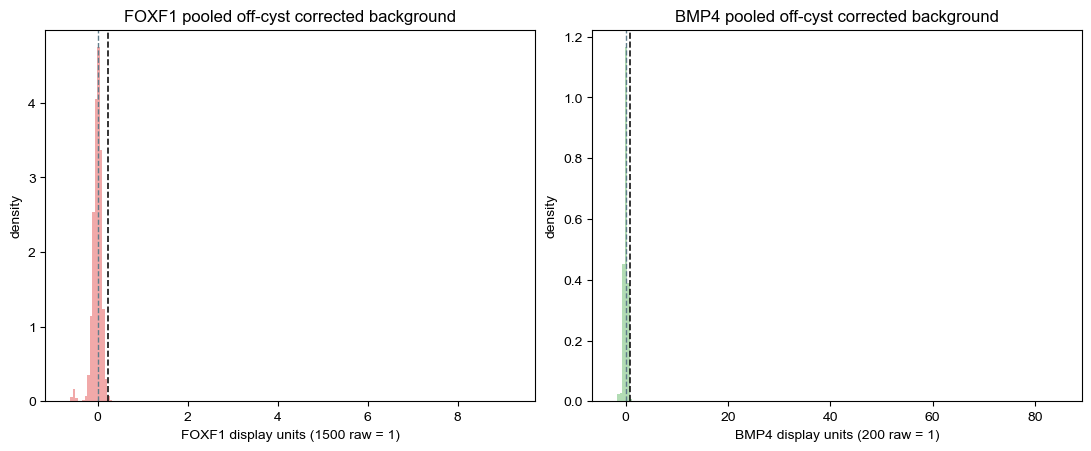

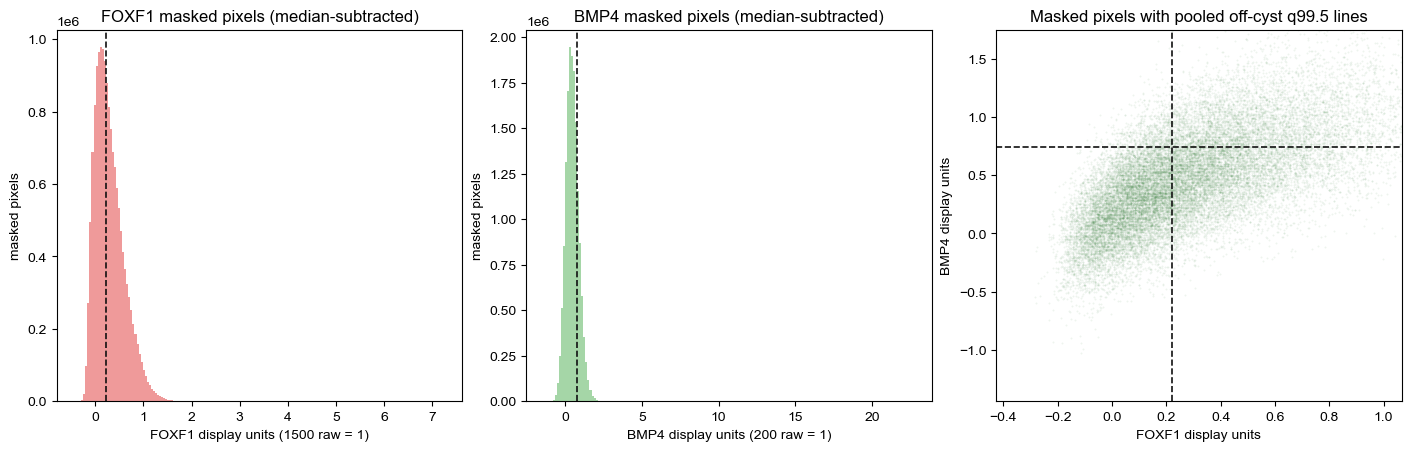

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.4), constrained_layout=True)

axes[0].hist(foxf1_bg_all_display, bins=180, color="#ef9a9a", edgecolor="none", alpha=0.85, density=True)
axes[0].axvline(0.0, color="#607d8b", linewidth=1.0, linestyle="--")
axes[0].axvline(foxf1_global_threshold_display, color="#111111", linewidth=1.2, linestyle="--")
axes[0].set_title("FOXF1 pooled off-cyst corrected background")
axes[0].set_xlabel("FOXF1 display units (1500 raw = 1)")
axes[0].set_ylabel("density")

axes[1].hist(bmp4_bg_all_display, bins=180, color="#a5d6a7", edgecolor="none", alpha=0.85, density=True)
axes[1].axvline(0.0, color="#607d8b", linewidth=1.0, linestyle="--")
axes[1].axvline(bmp4_global_threshold_display, color="#111111", linewidth=1.2, linestyle="--")
axes[1].set_title("BMP4 pooled off-cyst corrected background")
axes[1].set_xlabel("BMP4 display units (200 raw = 1)")
axes[1].set_ylabel("density")

fig.savefig(HIST_FIG_PNG, dpi=250, bbox_inches="tight")
print("Saved:", HIST_FIG_PNG)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True)

axes[0].hist(foxf1_all_display, bins=180, color="#ef9a9a", edgecolor="none")
axes[0].axvline(foxf1_global_threshold_display, color="#111111", linewidth=1.2, linestyle="--")
axes[0].set_title("FOXF1 masked pixels (median-subtracted)")
axes[0].set_xlabel("FOXF1 display units (1500 raw = 1)")
axes[0].set_ylabel("masked pixels")

axes[1].hist(bmp4_all_display, bins=180, color="#a5d6a7", edgecolor="none")
axes[1].axvline(bmp4_global_threshold_display, color="#111111", linewidth=1.2, linestyle="--")
axes[1].set_title("BMP4 masked pixels (median-subtracted)")
axes[1].set_xlabel("BMP4 display units (200 raw = 1)")
axes[1].set_ylabel("masked pixels")

rng = np.random.default_rng(7)
idx = rng.choice(foxf1_all_display.size, size=min(25000, foxf1_all_display.size), replace=False)
axes[2].scatter(
    foxf1_all_display[idx],
    bmp4_all_display[idx],
    s=2,
    alpha=0.08,
    color="#2e7d32",
    linewidths=0,
)
axes[2].axvline(foxf1_global_threshold_display, color="#111111", linewidth=1.2, linestyle="--")
axes[2].axhline(bmp4_global_threshold_display, color="#111111", linewidth=1.2, linestyle="--")
axes[2].set_title("Masked pixels with pooled off-cyst q99.5 lines")
axes[2].set_xlabel("FOXF1 display units")
axes[2].set_ylabel("BMP4 display units")
axes[2].set_xlim(axes[2].get_xlim()[0], foxf1_display_max)
axes[2].set_ylim(axes[2].get_ylim()[0], bmp4_display_max)

plt.show()

In [ ]:
def plot_density_panel_from_arrays(
    ax,
    x_values: np.ndarray,
    y_values: np.ndarray,
    title: str,
    bins: int = 96,
    contour_sigma: float = 1.3,
    clip_quantile: float | None = None,
    x_threshold: float = 0.0,
    y_threshold: float = 0.0,
):
    x_values = np.asarray(x_values, dtype=np.float32)
    y_values = np.asarray(y_values, dtype=np.float32)
    valid = np.isfinite(x_values) & np.isfinite(y_values)
    x_values = x_values[valid]
    y_values = y_values[valid]
    x_range = _density_range_from_values(x_values)
    y_range = _density_range_from_values(y_values)
    counts, x_edges, y_edges = np.histogram2d(
        x_values,
        y_values,
        bins=int(bins),
        range=[x_range, y_range],
    )
    display_grid = counts.astype(np.float64)
    if np.nanmax(display_grid) > 0:
        display_grid = display_grid / np.nanmax(display_grid)
    if clip_quantile is not None and np.any(display_grid > 0):
        positive = display_grid[display_grid > 0]
        clip_value = float(np.quantile(positive, float(clip_quantile)))
        if np.isfinite(clip_value) and clip_value > 0:
            display_grid = np.clip(display_grid, 0.0, clip_value) / clip_value
    smoothed = ndi.gaussian_filter(display_grid, sigma=float(contour_sigma))
    mesh = ax.pcolormesh(x_edges, y_edges, display_grid.T, shading="auto", cmap="YlGn", vmin=0.0, vmax=1.0)
    if float(np.nanmax(smoothed)) > 0:
        ax.contour(
            0.5 * (x_edges[:-1] + x_edges[1:]),
            0.5 * (y_edges[:-1] + y_edges[1:]),
            smoothed.T,
            levels=[0.15, 0.35, 0.55, 0.75],
            colors="#2f2f2f",
            linewidths=0.9,
        )
    ax.axvline(float(x_threshold), color="#111111", linewidth=1.2, linestyle="--")
    ax.axhline(float(y_threshold), color="#111111", linewidth=1.2, linestyle="--")
    ax.set_xlim(float(x_edges[0]), min(float(x_edges[-1]), foxf1_display_max))
    ax.set_ylim(float(y_edges[0]), min(float(y_edges[-1]), bmp4_display_max))
    ax.set_xlabel("FOXF1 Intensity (arb. norm.; 1500 raw = 1)")
    ax.set_ylabel("BMP4 Intensity (arb. norm.; 200 raw = 1)")
    ax.set_title(title)
    return mesh


pooled_quadrant_lookup = dict(zip(pooled_quadrant_df["quadrant_label"], pooled_quadrant_df["fraction"]))
median_quadrant_lookup = dict(zip(quadrant_summary_df["quadrant_label"], quadrant_summary_df["median_fraction"]))

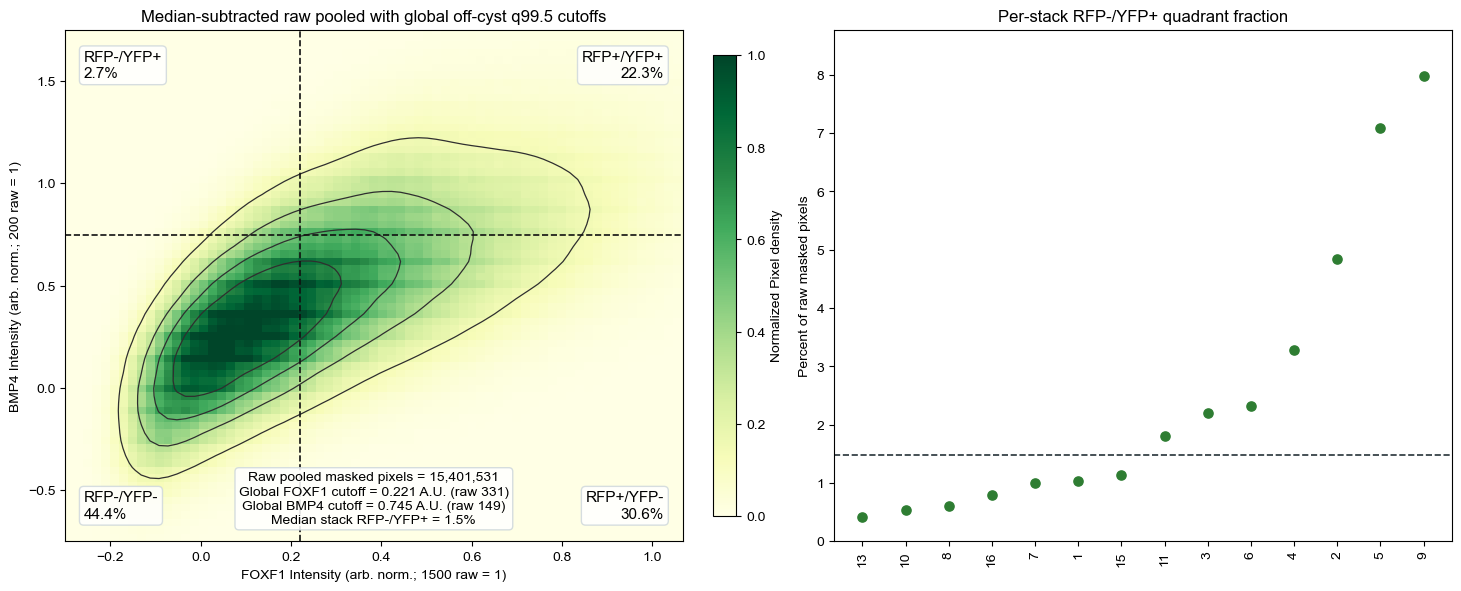

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), constrained_layout=True)
mesh = plot_density_panel_from_arrays(
    axes[0],
    foxf1_all_display,
    bmp4_all_display,
    title="Median-subtracted raw pooled with global off-cyst q99.5 cutoffs",
    bins=BINS,
    contour_sigma=CONTOUR_SIGMA,
    clip_quantile=DISPLAY_CLIP_QUANTILE,
    x_threshold=foxf1_global_threshold_display,
    y_threshold=bmp4_global_threshold_display,
)

quadrant_text_positions = {
    "RFP-/YFP+": (0.03, 0.96, "left", "top"),
    "RFP+/YFP+": (0.97, 0.96, "right", "top"),
    "RFP-/YFP-": (0.03, 0.04, "left", "bottom"),
    "RFP+/YFP-": (0.97, 0.04, "right", "bottom"),
}
for label, (x_pos, y_pos, ha, va) in quadrant_text_positions.items():
    axes[0].text(
        x_pos,
        y_pos,
        f"{label}\n{100.0 * float(pooled_quadrant_lookup[label]):.1f}%",
        transform=axes[0].transAxes,
        ha=ha,
        va=va,
        fontsize=11,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "#cfd8dc", "boxstyle": "round,pad=0.28"},
    )

summary_lines = [
    f"Raw pooled masked pixels = {foxf1_all_corr.size:,}",
    f"Global FOXF1 cutoff = {foxf1_global_threshold_display:.3f} A.U. (raw {foxf1_global_threshold:.0f})",
    f"Global BMP4 cutoff = {bmp4_global_threshold_display:.3f} A.U. (raw {bmp4_global_threshold:.0f})",
    f"Median stack RFP-/YFP+ = {100.0 * float(median_quadrant_lookup['RFP-/YFP+']):.1f}%",
]
axes[0].text(
    0.50,
    0.03,
    "\n".join(summary_lines),
    transform=axes[0].transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.88, "edgecolor": "#cfd8dc", "boxstyle": "round,pad=0.28"},
)

yfp_only_df = (
    stack_quadrant_df.loc[stack_quadrant_df["quadrant_label"] == "RFP-/YFP+"]
    .copy()
    .sort_values("fraction")
    .reset_index(drop=True)
)
x = np.arange(len(yfp_only_df), dtype=float)
axes[1].scatter(x, 100.0 * yfp_only_df["fraction"].to_numpy(dtype=float), color="#2e7d32", s=44, zorder=3)
axes[1].axhline(
    100.0 * float(yfp_only_df["fraction"].median()),
    color="#263238",
    linestyle="--",
    linewidth=1.2,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(yfp_only_df["position_label"], rotation=90)
axes[1].set_ylabel("Percent of raw masked pixels")
axes[1].set_title("Per-stack RFP-/YFP+ quadrant fraction")
axes[1].set_ylim(0.0, max(5.0, 100.0 * float(yfp_only_df["fraction"].max()) * 1.1))

fig.colorbar(mesh, ax=axes[0], shrink=0.9, label="Normalized Pixel density")

plt.show()

            ## Final Export Figure

            This last cell exports only the cleaned manuscript-facing density plot.
            

Saved: <repository>/imaging/foxf1_bmp4_day2_fig2g/results/figures/03_foxf1_bmp4_density_global_q995.png
Saved: <repository>/imaging/foxf1_bmp4_day2_fig2g/results/figures/03_foxf1_bmp4_density_global_q995.svg
Saved: <repository>/imaging/foxf1_bmp4_day2_fig2g/results/figures/03_foxf1_bmp4_density_global_q995.pdf


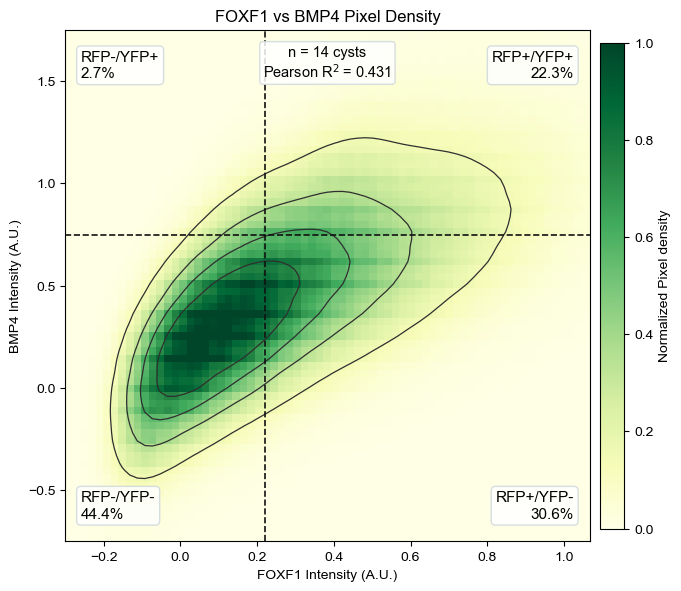

In [ ]:
fig, ax = plt.subplots(figsize=(6.7, 5.8), constrained_layout=True)
plot_density_panel_from_arrays(
    ax,
    foxf1_all_display,
    bmp4_all_display,
    title="FOXF1 vs BMP4 Pixel Density",
    bins=BINS,
    contour_sigma=CONTOUR_SIGMA,
    clip_quantile=DISPLAY_CLIP_QUANTILE,
    x_threshold=foxf1_global_threshold_display,
    y_threshold=bmp4_global_threshold_display,
)

quadrant_text_positions = {
    "RFP-/YFP+": (0.03, 0.96, "left", "top"),
    "RFP+/YFP+": (0.97, 0.96, "right", "top"),
    "RFP-/YFP-": (0.03, 0.04, "left", "bottom"),
    "RFP+/YFP-": (0.97, 0.04, "right", "bottom"),
}
for label, (x_pos, y_pos, ha, va) in quadrant_text_positions.items():
    ax.text(
        x_pos,
        y_pos,
        f"{label}\n{100.0 * float(pooled_quadrant_lookup[label]):.1f}%",
        transform=ax.transAxes,
        ha=ha,
        va=va,
        fontsize=11,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "#cfd8dc", "boxstyle": "round,pad=0.28"},
    )

ax.set_xlabel("FOXF1 Intensity (A.U.)")
ax.set_ylabel("BMP4 Intensity (A.U.)")
ax.text(
    0.50,
    0.97,
    f"n = {len(manifest_df)} cysts\nPearson R$^2$ = {pearson_r_squared:.3f}",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10.5,
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "#cfd8dc", "boxstyle": "round,pad=0.24"},
)
colorbar = fig.colorbar(mesh, ax=ax, location="right", pad=0.02, shrink=0.95)
colorbar.set_label("Normalized Pixel density")

if SAVE_MAIN_FIGURE:
    fig.savefig(MAIN_FIG_PNG, dpi=300, bbox_inches="tight")
    fig.savefig(MAIN_FIG_SVG, bbox_inches="tight")
    fig.savefig(MAIN_FIG_PDF, bbox_inches="tight")
    print("Saved:", MAIN_FIG_PNG)
    print("Saved:", MAIN_FIG_SVG)
    print("Saved:", MAIN_FIG_PDF)

plt.show()

In [ ]:
# Added for the published repository; not part of the original analysis.
# Writes what the Fig 2g panel is drawn from to this lane's derived/ directory, so that
# scripts/render_fig2g_panel.py can redraw the panel without the raw images. It only reads the
# arrays and settings computed above:
#   fig2g_histogram_counts.tsv  pixels in each of the panel's BINS x BINS bins, before normalisation
#   fig2g_bin_edges.tsv         the bin edges, in display units
#   fig2g_summary.tsv           n, pixel count, cutoffs, display settings, quadrant pixel counts,
#                               and the sums over the pixels that give the Pearson R2 above
import math

DERIVED_DIR = ROOT / "derived"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

# The binning inside plot_density_panel_from_arrays: finite pixels, range from their quantiles.
fig_x = np.asarray(foxf1_all_display, dtype=np.float32)
fig_y = np.asarray(bmp4_all_display, dtype=np.float32)
fig_valid = np.isfinite(fig_x) & np.isfinite(fig_y)
fig_counts, fig_x_edges, fig_y_edges = np.histogram2d(
    fig_x[fig_valid],
    fig_y[fig_valid],
    bins=int(BINS),
    range=[_density_range_from_values(fig_x[fig_valid]), _density_range_from_values(fig_y[fig_valid])],
)
fig_x_index, fig_y_index = np.meshgrid(
    np.arange(fig_counts.shape[0]), np.arange(fig_counts.shape[1]), indexing="ij"
)
pd.DataFrame(
    {
        "foxf1_bin": fig_x_index.ravel(),
        "bmp4_bin": fig_y_index.ravel(),
        "pixel_count": fig_counts.ravel().astype(np.int64),
    }
).to_csv(DERIVED_DIR / "fig2g_histogram_counts.tsv", sep="\t", index=False)
pd.concat(
    [
        pd.DataFrame({"axis": "foxf1", "edge_index": np.arange(fig_x_edges.size), "edge": fig_x_edges}),
        pd.DataFrame({"axis": "bmp4", "edge_index": np.arange(fig_y_edges.size), "edge": fig_y_edges}),
    ]
).to_csv(DERIVED_DIR / "fig2g_bin_edges.tsv", sep="\t", index=False)

# pearson_r_squared above is np.corrcoef over foxf1_all_display (x) and bmp4_all_display (y).
# These sums over the same values give it back:
# r = (n*sum_xy - sum_x*sum_y) / sqrt((n*sum_xx - sum_x**2) * (n*sum_yy - sum_y**2)).
fig_x64 = foxf1_all_display.astype(np.float64)
fig_y64 = bmp4_all_display.astype(np.float64)
summary_rows = [
    ("n_cysts", len(manifest_df), "image stacks pooled; the n printed on the panel"),
    ("pixel_count", int(foxf1_all_display.size), "in-mask pixels pooled over all z planes of all stacks"),
    ("foxf1_cutoff_raw", float(foxf1_global_threshold), "FOXF1 cutoff, background-subtracted intensity"),
    ("bmp4_cutoff_raw", float(bmp4_global_threshold), "BMP4 cutoff, background-subtracted intensity"),
    ("foxf1_cutoff_display", float(foxf1_global_threshold_display), "FOXF1 cutoff in display units (dashed line)"),
    ("bmp4_cutoff_display", float(bmp4_global_threshold_display), "BMP4 cutoff in display units (dashed line)"),
    ("foxf1_display_scale_raw", float(FOXF1_DISPLAY_SCALE_RAW), "raw FOXF1 intensity equal to 1 display unit"),
    ("bmp4_display_scale_raw", float(BMP4_DISPLAY_SCALE_RAW), "raw BMP4 intensity equal to 1 display unit"),
    ("foxf1_axis_max_display", float(foxf1_display_max), "largest x-axis limit, display units"),
    ("bmp4_axis_max_display", float(bmp4_display_max), "largest y-axis limit, display units"),
    ("bins", int(BINS), "bins per axis"),
    ("display_clip_quantile", float(DISPLAY_CLIP_QUANTILE), "colour scale clipped at this quantile of non-empty bins"),
    ("contour_sigma", float(CONTOUR_SIGMA), "Gaussian smoothing for the contours, in bins"),
]
for label, fn in QUADRANT_LABELS:
    quadrant = fn(foxf1_all_display, bmp4_all_display, foxf1_global_threshold_display, bmp4_global_threshold_display)
    summary_rows.append((f"pixels_{label}", int(np.count_nonzero(quadrant)), f"pixels in quadrant {label}"))
summary_rows += [
    ("sum_x", math.fsum(fig_x64), "sum of FOXF1 display values (x)"),
    ("sum_y", math.fsum(fig_y64), "sum of BMP4 display values (y)"),
    ("sum_xx", math.fsum(fig_x64 * fig_x64), "sum of x squared"),
    ("sum_yy", math.fsum(fig_y64 * fig_y64), "sum of y squared"),
    ("sum_xy", math.fsum(fig_x64 * fig_y64), "sum of x times y"),
    ("pearson_r_squared", float(pearson_r_squared), "as computed above with np.corrcoef"),
]
pd.DataFrame(
    [(name, repr(value) if isinstance(value, float) else str(value), text) for name, value, text in summary_rows],
    columns=["quantity", "value", "description"],
).to_csv(DERIVED_DIR / "fig2g_summary.tsv", sep="\t", index=False)
for name in ["fig2g_histogram_counts.tsv", "fig2g_bin_edges.tsv", "fig2g_summary.tsv"]:
    print("Wrote:", (DERIVED_DIR / name).relative_to(ROOT))

Wrote: derived/fig2g_histogram_counts.tsv
Wrote: derived/fig2g_bin_edges.tsv
Wrote: derived/fig2g_summary.tsv
